HR Attrition Analysis – Exploratory Data Analysis

Objective:

Analyze employee attrition patterns
Identify factors affecting employee turnover
Support insights later visualized in Power BI dashboard

Dataset Source:
Kaggle – IBM HR Analytics Dataset
Dataset contains employee demographic information, compensation data, satisfaction metrics, and attrition status for HR analysis.

Tools Used:
Python (Pandas, Matplotlib, Seaborn)

In [ ]:
## Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [35]:
df=pd.read_csv("HR_Cleaned.csv")

In [36]:
df.head()

,Age,Attrition BINARY,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,Tenure,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,80,0,8,0,1,6,Medium Tenure,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,80,1,10,3,3,10,Long Tenure,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,80,0,7,3,3,0,Low Tenure,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,80,0,8,3,3,8,Long Tenure,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,80,1,6,3,3,2,Low Tenure,2,2,2


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition BINARY          1470 non-null   int64
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [38]:
df.describe()

,Age,Attrition BINARY,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [39]:
df.columns

Index(['Age', 'Attrition BINARY', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlySalary', 'Salary Band', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'Tenure', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')

Data Cleaning

In [40]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [41]:
df.isnull().sum()

Age                         0
Attrition BINARY            0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlySalary               0
Salary Band                 0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
Tenure                      0
YearsInCur

Basic Dataset Overview

In [42]:
df.shape

(1470, 36)

In [48]:
df['Attrition BINARY'].value_counts()

Attrition BINARY
0    1233
1     237
Name: count, dtype: int64

In [49]:
df['Attrition BINARY'].mean()*100

np.float64(16.122448979591837)

Exploratory Data Analysis (EDA)

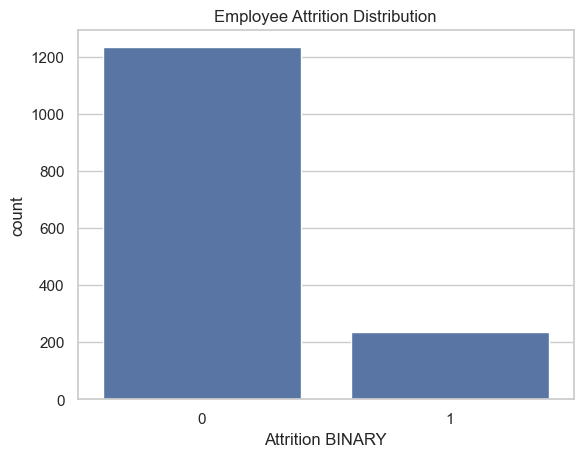

In [50]:
## Attrition Distribution
sns.countplot(x='Attrition BINARY', data=df)
plt.title("Employee Attrition Distribution")
plt.show()

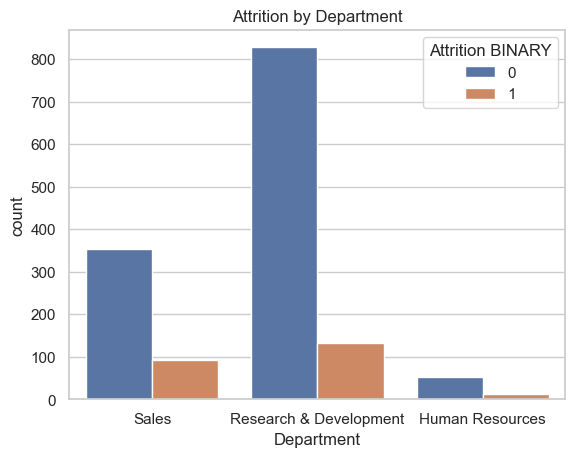

In [52]:
## Attrition by Department
sns.countplot(x='Department', hue='Attrition BINARY', data=df)
plt.title("Attrition by Department")
plt.show()

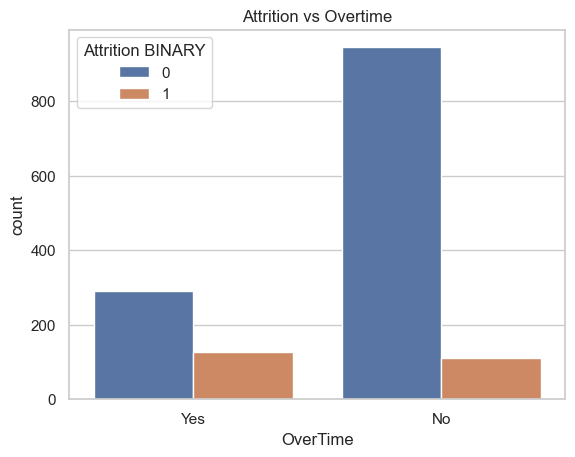

In [53]:
## Attrition vs Overtime
sns.countplot(x='OverTime', hue='Attrition BINARY', data=df)
plt.title("Attrition vs Overtime")
plt.show()

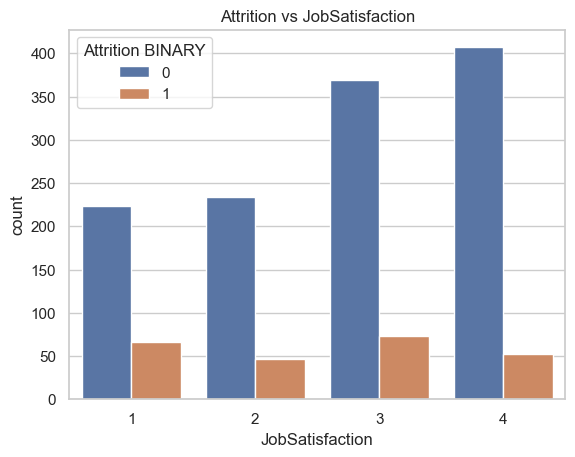

In [54]:
## Attrition vs JobSatisfaction
sns.countplot(x='JobSatisfaction',hue='Attrition BINARY', data=df)
plt.title("Attrition vs JobSatisfaction")
plt.show()

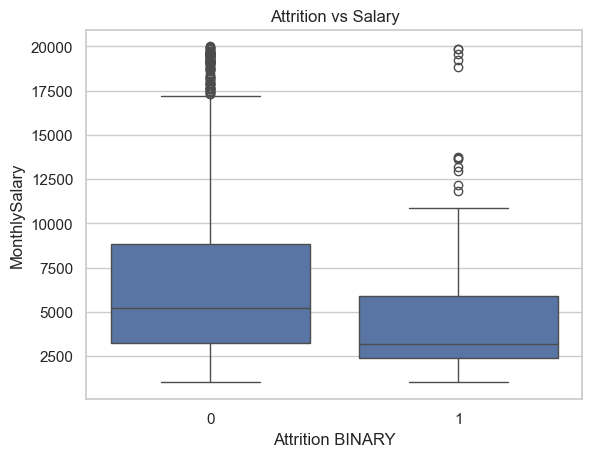

In [56]:
## Attrition vs Salary
sns.boxplot(x='Attrition BINARY',y='MonthlySalary',data=df)
plt.title('Attrition vs Salary')
plt.show()

Correlation Analysis

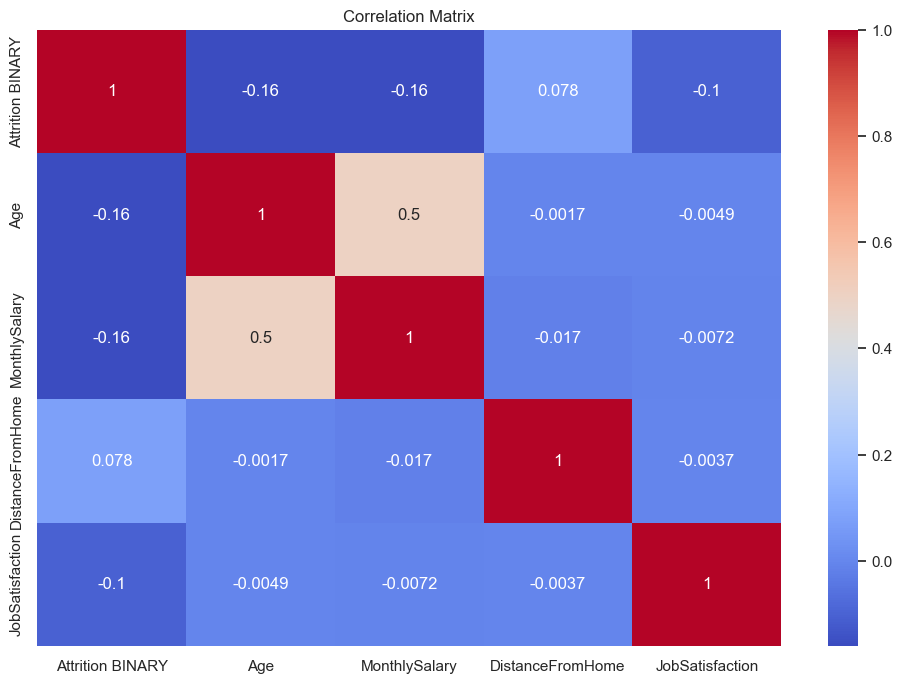

In [59]:
plt.figure(figsize=(12,8))
cols = ['Attrition BINARY','Age','MonthlySalary','DistanceFromHome','JobSatisfaction']
sns.heatmap(df[cols].corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Matrix")
plt.show()


Key Insights

Key Findings:

• Employees working overtime show significantly higher attrition.
• Low salary employees are more likely to leave.
• Job satisfaction strongly influences retention.
• Sales department shows higher attrition compared to other departments.

Link to Power BI Dashboard


Further analysis and visualization were performed using Power BI dashboard, which highlights attrition drivers and high-risk employees.